# `01-intro.ipynb`
- Langgraph 는 "흐름 제어"가 핵심
- 모든 노드가 공유하는 `State`

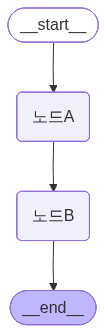

In [9]:
# Tiny Graph
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. State (각 노드마다 사용할 데이터들 집합 -> 메세지 히스토리도 포함)
# {'text': 'abcd'}
class MyState(TypedDict):
    text: str


# 2. Node를 만든다
def node_a(state: MyState):
    new_text = state['text'] + '-> A노드 통과 '
    return {'text': new_text} 


def node_b(state: MyState):
    new_text = state['text'] + '-> B노드 통과'
    return {'text': new_text} 


# 3. Node - Edge 연결한다
graph = StateGraph(MyState)  # 새로운 상태그래프. MyState를 모두 공유하기

graph.add_node('노드A', node_a)  # 새로운 노드 등록. 앞은 부를 이름, 뒤는 함수 이름
graph.add_node('노드B', node_b)

graph.add_edge(START, '노드A')    # graph.set_entry_point('노드A')
graph.add_edge('노드A', '노드B')  # 앞과 뒤를 잇는다.
graph.add_edge('노드B', END)      # graph.set_finish_point('노드B')

# 4. 그래프를 만든다(compile).
app = graph.compile()
app

In [10]:
app.invoke({'text': '아주 작은 그래프'})

{'text': '아주 작은 그래프-> A노드 통과 -> B노드 통과'}